# 506: Mean-Based Waterfall Contribution Plot

`503_contributions-updated.ipynb`'s waterfall plots stack component contributions
(`CO2_NZCO2`, `CO2_Negative`, `NonCO2_GHG`, `Residual`) using **median-of-medians**:
the median (across ensemble members) is taken per scenario, then the median (across
scenarios) of those per-scenario medians is used as the bar height. This is known to
not add up exactly - the stacked component bars don't necessarily sum to the plotted
2100 endpoint bar - because **median is not additive**
(`median(A) + median(B) != median(A + B)` in general), even though the underlying
per-member component decomposition (`ANTHROPOGENIC = CO2_NZCO2 + CO2_Negative +
NonCO2_GHG + Residual`) holds exactly for every individual ensemble member.

**Mean is additive.** Since every scenario has the same ensemble size (600 members),
the mean of per-scenario means equals the pooled mean across all members - and because
the per-member decomposition is exact, taking that (linear) mean at any level preserves
the identity exactly. This notebook reproduces *only* 503's waterfall plot (no other
503 analyses), swapping every median for a mean, so the stacked bars sum to the 2100
endpoint bar exactly (verified explicitly at the end).

Percentile-based error bars (p17/p83 of the per-scenario-mean distribution across
scenarios) are kept as in 503 - only the central bar heights change from median-based
to mean-based, since additivity is a property of the central-tendency statistic, not
of the uncertainty range shown around it.

In [1]:
import os
from pathlib import Path

import dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dotenv.load_dotenv()

OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
PLOT_FOLDER = OUTPUT_FOLDER / "plots"
PLOT_FOLDER.mkdir(parents=True, exist_ok=True)

MANIFEST_ID = "regenerated"
METRICS_FILE = OUTPUT_FOLDER / f"500b_component_metrics_extended_{MANIFEST_ID}.csv"

GROUPS = [
    "Scenarios (NZCO2)",
    "Scenarios (NZGHG)",
    "Stylised Variants (NZCO2-hold)",
    "Stylised Variants (NZGHG-hold)",
]

COMPONENTS = ["ANTHROPOGENIC", "CO2_NZCO2", "CO2_Negative", "NonCO2_GHG", "Residual"]
DELTA_COMPONENTS = ["CO2_NZCO2", "CO2_Negative", "NonCO2_GHG", "Residual"]

In [2]:
metrics_df = pd.read_csv(METRICS_FILE, index_col=0)
print(f"Total rows: {len(metrics_df)}")
metrics_df["scenario_group"].value_counts()

Total rows: 1405200


scenario_group
Scenarios (NZCO2)                 470400
Stylised Variants (NZCO2-hold)    470400
Stylised Variants (NZGHG-hold)    232200
Scenarios (NZGHG)                 232200
Name: count, dtype: int64

## Per-Scenario Means and Mean-of-Means Group Statistics

In [3]:
# Per-scenario MEAN (across ensemble members) of the endpoint GSAT levels - used for
# the start (NZCO2) and end (2100) bars, matching 503's per-scenario aggregation step
# but with mean instead of median.
value_cols = [c for c in metrics_df.columns if c.startswith("GSAT|")]
scenario_means = metrics_df.groupby(["model", "scenario", "scenario_group"])[value_cols].mean()

scenario_means_by_group = {
    group: scenario_means[scenario_means.index.get_level_values("scenario_group") == group]
    for group in GROUPS
}

In [4]:
def calc_mean_of_mean_by_group(metrics_df, components, groups, extraction_mode="netzero_co2"):
    """For each delta component, compute per-scenario mean (across members), then the
    mean-of-means across scenarios (the additive bar-height statistic), alongside
    percentile-of-percentile error bars (p05/p17/p83/p95), per scenario_group.

    Mirrors 503's calc_percentile_of_percentile/calc_pop_by_group, with "median"
    replaced by "mean" for the central bar-height statistic only.
    """
    delta_cols = [f"GSAT|{c}|delta_{extraction_mode}" for c in components if f"GSAT|{c}|delta_{extraction_mode}" in metrics_df.columns]
    quantiles = {"p05": 0.05, "p17": 0.17, "p83": 0.83, "p95": 0.95}

    scenario_stats = metrics_df.groupby(["model", "scenario", "scenario_group"])[delta_cols].agg(
        ["mean"] + [lambda x, q=q: x.quantile(q) for q in quantiles.values()]
    )
    stat_names = ["mean"] + list(quantiles.keys())
    scenario_stats.columns = [f"{col}|{name}" for col in delta_cols for name in stat_names]

    results = {}
    for group in groups:
        gdf = scenario_stats[scenario_stats.index.get_level_values("scenario_group") == group]
        rows = {}
        for comp in components:
            col_base = f"GSAT|{comp}|delta_{extraction_mode}"
            if f"{col_base}|mean" not in gdf.columns:
                continue
            rows[comp] = {
                "mean_of_mean": gdf[f"{col_base}|mean"].mean(),
                "p05_of_p05": gdf[f"{col_base}|p05"].quantile(0.05),
                "p17_of_p17": gdf[f"{col_base}|p17"].quantile(0.17),
                "p83_of_p83": gdf[f"{col_base}|p83"].quantile(0.83),
                "p95_of_p95": gdf[f"{col_base}|p95"].quantile(0.95),
            }
        if rows:
            df = pd.DataFrame(rows).T
            df.index.name = "Component"
            results[group] = df
    return results


mean_of_mean_by_group_netzero_co2 = calc_mean_of_mean_by_group(metrics_df, DELTA_COMPONENTS, GROUPS, "netzero_co2")
mean_of_mean_by_group_netzero_co2["Scenarios (NZCO2)"]

,mean_of_mean,p05_of_p05,p17_of_p17,p83_of_p83,p95_of_p95
Component,,,,,
CO2_NZCO2,-0.021098,-0.150750,-0.091580,0.036319,0.131279
CO2_Negative,-0.077524,-0.331711,-0.187213,-0.000019,0.001549
NonCO2_GHG,-0.020719,-0.130971,-0.074218,0.021656,0.063009
Residual,0.002732,-0.096476,-0.054839,0.086305,0.225884


## Mean-Based Waterfall Plot

In [5]:
def create_waterfall_plot_mean(pop_stats, scenario_means_subset, title, ax):
    color_start = '#0F0FFF'
    color_delta = {
        'CO2_NZCO2': '#FF0B00',
        'CO2_Negative': '#00E3DB',
        'NonCO2_GHG': '#4CA2FF',
        'Residual': '#C92EB9'
    }
    color_end = '#0F0FFF'

    error_kw = {'ecolor': 'black', 'alpha': 0.5, 'capsize': 4, 'capthick': 1.2}
    bar_kw = {'width': 0.6, 'edgecolor': 'black', 'linewidth': 0.8}

    # Start (NZCO2) and end (2100) bars: mean of per-scenario means, with p17/p83
    # error bars from the per-scenario-mean distribution across scenarios
    nzco2_mean = scenario_means_subset["GSAT|ANTHROPOGENIC|netzero_co2"].mean()
    nzco2_p17 = scenario_means_subset["GSAT|ANTHROPOGENIC|netzero_co2"].quantile(0.17)
    nzco2_p83 = scenario_means_subset["GSAT|ANTHROPOGENIC|netzero_co2"].quantile(0.83)

    y2100_mean = scenario_means_subset["GSAT|ANTHROPOGENIC|2100"].mean()
    y2100_p17 = scenario_means_subset["GSAT|ANTHROPOGENIC|2100"].quantile(0.17)
    y2100_p83 = scenario_means_subset["GSAT|ANTHROPOGENIC|2100"].quantile(0.83)

    x_positions = [0, 1, 2, 3, 4, 5]
    labels = ["NZCO2\n[ANTHRO]", "ZEC*", "CO$_2$\nNeg", "Non-CO$_2$\nGHG", "Resid.", "2100\n[ANTHRO]"]

    ax.bar(0, nzco2_mean, color=color_start,
           yerr=[[nzco2_mean - nzco2_p17], [nzco2_p83 - nzco2_mean]],
           error_kw=error_kw, **bar_kw)

    # Boundary levels for the connector lines: where each bar ends and the next starts
    half_width = bar_kw["width"] / 2
    connector_kw = {"linestyle": ":", "color": "gray", "linewidth": 1, "zorder": 1}
    boundaries = [nzco2_mean]

    bottom = nzco2_mean
    for i, comp in enumerate(DELTA_COMPONENTS):
        if comp in pop_stats.index:
            delta_mean = pop_stats.loc[comp, "mean_of_mean"]
            delta_p17 = pop_stats.loc[comp, "p17_of_p17"]
            delta_p83 = pop_stats.loc[comp, "p83_of_p83"]

            ax.bar(i + 1, delta_mean, bottom=bottom, color=color_delta[comp],
                   yerr=[[delta_mean - delta_p17], [delta_p83 - delta_mean]],
                   error_kw=error_kw, **bar_kw)
            bottom += delta_mean
            boundaries.append(bottom)

    ax.bar(5, y2100_mean, color=color_end,
           yerr=[[y2100_mean - y2100_p17], [y2100_p83 - y2100_mean]],
           error_kw=error_kw, **bar_kw)

    # Dotted connector lines between each bar's ending level and the next bar's start
    for i, boundary in enumerate(boundaries):
        ax.plot([i + half_width, i + 1 - half_width], [boundary, boundary], **connector_kw)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_ylabel("GSAT (\u00b0C)", fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(alpha=0.3, axis='y')
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

    return ax, bottom, y2100_mean

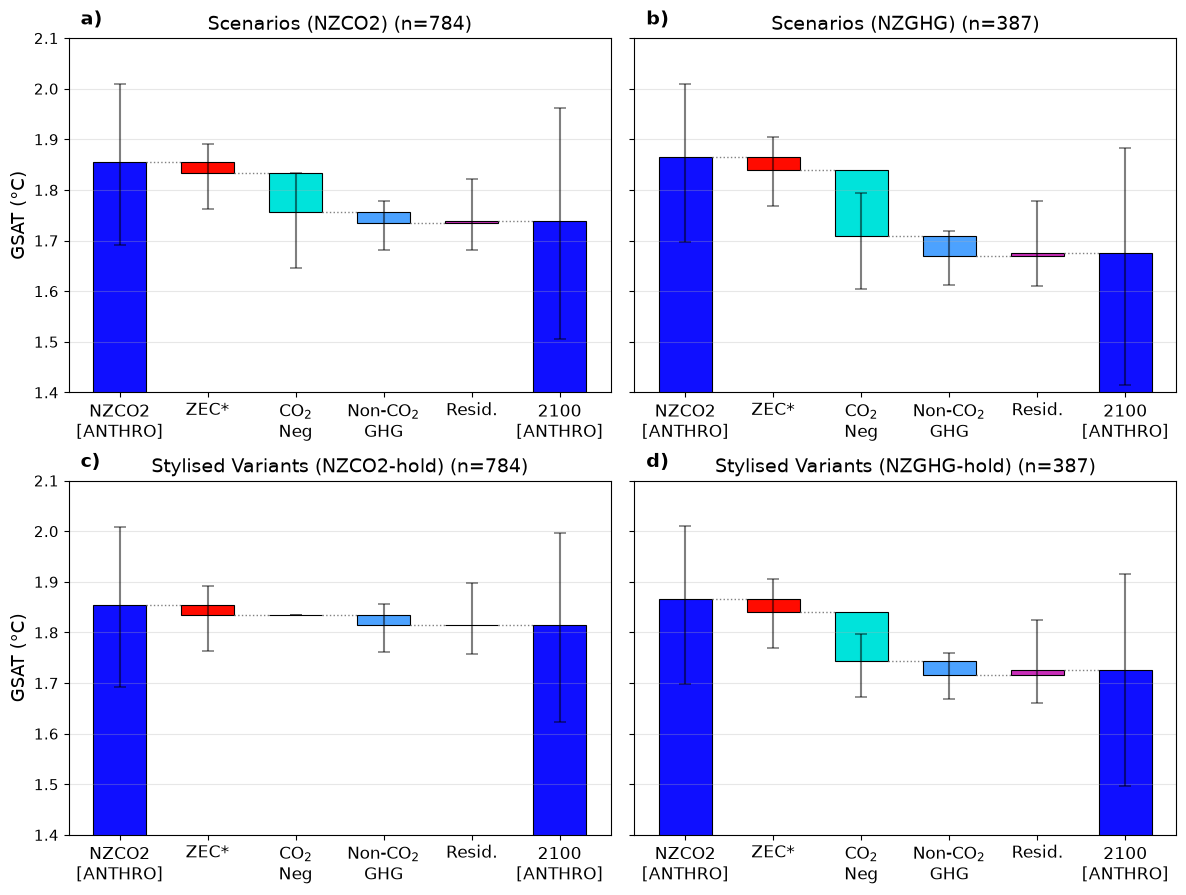

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
axes = axes.flatten()

additivity_check = []
for ax, group in zip(axes, GROUPS):
    _, stacked_total, y2100_mean = create_waterfall_plot_mean(
        mean_of_mean_by_group_netzero_co2[group],
        scenario_means_by_group[group],
        f"{group} (n={len(scenario_means_by_group[group])})",
        ax,
    )
    additivity_check.append({"scenario_group": group, "stacked_total": stacked_total, "y2100_mean": y2100_mean, "abs_diff": abs(stacked_total - y2100_mean)})

for ax in axes[1::2]:
    ax.set_ylabel("")

for ax in axes:
    ax.set_ylim(1.4, 2.1)

plt.tight_layout()

labels_ab = ["a)", "b)", "c)", "d)"]
for ax, label in zip(axes, labels_ab):
    x = ax.get_position().x0
    y = ax.get_position().y1
    fig.text(x + 0.01, y + 0.01, label, fontsize=14, fontweight="bold", va="bottom")

plt.savefig(PLOT_FOLDER / "506_waterfall_contributions_mean_based.png", dpi=150, bbox_inches="tight")
plt.show()

## Verify Additivity

The stacked bars (start + sum of component deltas) should now equal the 2100 endpoint
bar exactly, unlike the median-based version in 503.

In [7]:
additivity_df = pd.DataFrame(additivity_check)
print("Stacked-total vs. 2100-endpoint-bar check (mean-based, should be ~0):")
print(additivity_df.to_string(index=False))
assert additivity_df["abs_diff"].max() < 1e-8, "Waterfall bars do not add up exactly - unexpected"
print("\nPASS: stacked component bars sum to the 2100 endpoint bar exactly, for every scenario group.")

Stacked-total vs. 2100-endpoint-bar check (mean-based, should be ~0):
                scenario_group  stacked_total  y2100_mean     abs_diff
             Scenarios (NZCO2)       1.738010    1.738010 4.440892e-16
             Scenarios (NZGHG)       1.674671    1.674671 2.220446e-16
Stylised Variants (NZCO2-hold)       1.815554    1.815554 0.000000e+00
Stylised Variants (NZGHG-hold)       1.724990    1.724990 0.000000e+00

PASS: stacked component bars sum to the 2100 endpoint bar exactly, for every scenario group.
